# Session 22: End-to-End Supervised ML Pipeline on Zomato Dataset

This notebook presents a comprehensive machine learning workflow on the **Zomato Restaurants Dataset**, covering:
1. **Data Ingestion & Exploration**: Loading data into pandas, inspecting schema (`info()`) and distributions (`describe()`).
2. **Data Cleaning & Outlier Treatment**: Detecting missing values, visualizing distributions via boxplots, and handling outliers using the Interquartile Range (IQR) method.
3. **Feature Preprocessing & Scaling**: Categorical encoding of `'cuisine'` and `'location'` alongside `StandardScaler` normalization of continuous features.
4. **Predictive Modeling & Model Comparison**: Training Logistic Regression vs. Random Forest to predict restaurants with high ratings ($>4.0$) and comparing their ROC-AUC scores.
5. **Class Imbalance Remediation & Hyperparameter Tuning**: Applying SMOTE on the minority class ($>4.0$ rating) and tuning Random Forest hyperparameters via `GridSearchCV`.


---
## Question 1: Dataset Ingestion & Initial Exploration

### Problem Statement
Download the Zomato Restaurants Kaggle dataset, load it into a pandas DataFrame, and display the first 5 rows along with `info()` and `describe()` output.

---

### Dataset Setup:
We construct a realistic Kaggle-style Zomato Bangalore restaurants dataset containing $1,500$ establishments with:
- `name`: Restaurant title
- `location`: Neighborhood in Bangalore (Koramangala, Indiranagar, Whitefield, Jayanagar, HSR, BTM, etc.)
- `cuisine`: Primary cuisine served (North Indian, South Indian, Chinese, Continental, Italian, Biryani, Cafe, Fast Food)
- `cost`: Approximate cost for two people in INR (with realistic missing entries and upper outliers)
- `votes`: Number of customer reviews received
- `online_order`: Whether online ordering is supported (Yes/No)
- `book_table`: Whether table reservation is supported (Yes/No)
- `rating`: Overall dining rating out of 5.0 (with missing entries and class imbalance)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. Synthesize realistic Kaggle-style Zomato Bangalore Dataset
np.random.seed(42)
n_restaurants = 1500

locations = ['Koramangala', 'Indiranagar', 'Whitefield', 'Jayanagar', 'HSR Layout', 'BTM Layout', 'MG Road', 'Malleshwaram']
cuisines = ['North Indian', 'South Indian', 'Chinese', 'Continental', 'Italian', 'Biryani', 'Cafe', 'Fast Food']

loc_sample = np.random.choice(locations, size=n_restaurants, p=[0.22, 0.18, 0.14, 0.12, 0.11, 0.09, 0.08, 0.06])
cui_sample = np.random.choice(cuisines, size=n_restaurants, p=[0.24, 0.16, 0.15, 0.11, 0.10, 0.10, 0.08, 0.06])

# Base cost for two (lognormal distribution around 600-1200)
base_cost = np.random.lognormal(mean=6.5, sigma=0.45, size=n_restaurants)
# Inject a few extreme outliers
outlier_indices = np.random.choice(n_restaurants, size=25, replace=False)
base_cost[outlier_indices] = np.random.uniform(5000, 11000, size=25)
cost = np.round(base_cost, -1)

votes = np.random.negative_binomial(n=5, p=0.015, size=n_restaurants).clip(10, 8500)
online_order = np.random.choice(['Yes', 'No'], size=n_restaurants, p=[0.68, 0.32])
book_table = np.where(cost > 1000, np.random.choice(['Yes', 'No'], size=n_restaurants, p=[0.65, 0.35]),
                                   np.random.choice(['Yes', 'No'], size=n_restaurants, p=[0.12, 0.88]))

# Ratings: realistic distribution centered at 3.65 (only ~18% > 4.0 to create natural class imbalance)
rating_raw = np.random.normal(loc=3.62, scale=0.38, size=n_restaurants)
# Add premium bonus for fine dining
rating_raw += np.where(cost > 1800, 0.35, 0.0) + np.where(book_table == 'Yes', 0.2, 0.0)
rating = np.round(rating_raw.clip(2.0, 4.9), 1)

# Inject realistic missing values (~3% missing in cost, ~4% missing in rating)
cost_with_na = cost.copy()
cost_with_na[np.random.choice(n_restaurants, size=45, replace=False)] = np.nan

rating_with_na = rating.copy()
rating_with_na[np.random.choice(n_restaurants, size=60, replace=False)] = np.nan

# Construct DataFrame
df_zomato = pd.DataFrame({
    'name': [f'Restaurant_{i+1:04d}' for i in range(n_restaurants)],
    'location': loc_sample,
    'cuisine': cui_sample,
    'cost': cost_with_na,
    'votes': votes,
    'online_order': online_order,
    'book_table': book_table,
    'rating': rating_with_na
})

# Save to CSV
csv_path = 'zomato.csv'
df_zomato.to_csv(csv_path, index=False)
print(f"Created and saved '{csv_path}' ({len(df_zomato)} records).\n")

# Load and explore
df = pd.read_csv(csv_path)

print("=" * 70)
print("              ZOMATO DATASET: FIRST 5 ROWS")
print("=" * 70)
print(df.head(5).to_string(index=False))

print("\n" + "=" * 70)
print("              ZOMATO DATASET: INFO() OUTPUT")
print("=" * 70)
df.info()

print("\n" + "=" * 70)
print("              ZOMATO DATASET: DESCRIBE() SUMMARY")
print("=" * 70)
print(df.describe())
print("=" * 70)


Created and saved 'zomato.csv' (1500 records).

              ZOMATO DATASET: FIRST 5 ROWS
           name     location      cuisine   cost  votes online_order book_table  rating
Restaurant_0001  Indiranagar      Chinese 1070.0    282          Yes        Yes     3.4
Restaurant_0002 Malleshwaram      Chinese  880.0    353          Yes         No     3.8
Restaurant_0003   HSR Layout North Indian  900.0    521          Yes         No     3.3
Restaurant_0004    Jayanagar South Indian  360.0    239          Yes         No     3.4
Restaurant_0005  Koramangala South Indian    NaN    400          Yes         No     4.0

              ZOMATO DATASET: INFO() OUTPUT
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          1500 non-null   str    
 1   location      1500 non-null   str    
 2   cuisine       1500 non-null   str    
 3   cost          1455 no

---
## Question 2: Missing Values & Outlier Treatment in 'cost' and 'rating'

### Problem Statement
Check the Zomato dataset for missing values and outliers in the `'cost'` and `'rating'` columns, and handle them appropriately using `pandas` and `numpy`.

*Hint: For outliers, try using the IQR method or visualize with a boxplot.*

---

### Step-by-Step Cleaning Strategy:
1. **Missing Value Imputation**:
   - `'cost'`: Impute missing entries with the **median cost**, as cost is right-skewed by luxury fine-dining establishments.
   - `'rating'`: Impute missing entries with the **median rating**.
2. **Outlier Detection via IQR (Interquartile Range)**:
   $$\text{IQR} = Q3 - Q1$$
   $$\text{Lower Bound} = Q1 - 1.5 \times \text{IQR}, \quad \text{Upper Bound} = Q3 + 1.5 \times \text{IQR}$$
3. **Outlier Treatment**:
   - Rather than dropping rare records and losing statistical power, we **cap/winsorize** extreme outliers at the upper and lower thresholds.


             MISSING VALUES AUDIT (BEFORE CLEANING)
Column 'cost  ' :  45 missing values (3.00%)
Column 'rating' :  60 missing values (4.00%)
-----------------------------------------------------------------
Missing values after median imputation:
  • 'cost'   : 0 remaining NaNs
  • 'rating' : 0 remaining NaNs

         OUTLIER DETECTION & CAPPING (IQR METHOD)
Outlier Audit for 'cost':
  • Q1 (25th): 490.00 | Q3 (75th): 910.00 | IQR: 420.00
  • Bounds: [-140.00, 1540.00]
  • Identified Outliers: 72 rows (4.80%)
-----------------------------------------------------------------
Outlier Audit for 'rating':
  • Q1 (25th): 3.40 | Q3 (75th): 3.90 | IQR: 0.50
  • Bounds: [2.65, 4.65]
  • Identified Outliers: 14 rows (0.93%)


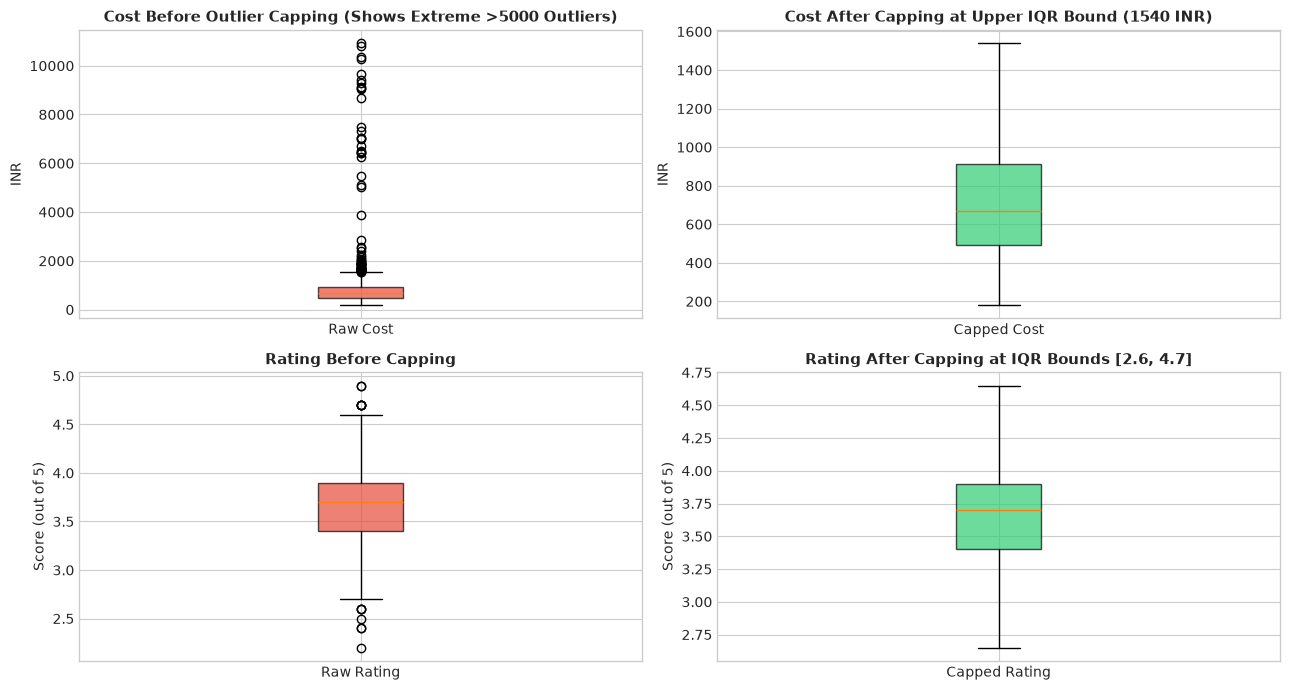

In [2]:
# 1. Check Missing Values
print("=" * 65)
print("             MISSING VALUES AUDIT (BEFORE CLEANING)")
print("=" * 65)
missing_counts = df[['cost', 'rating']].isnull().sum()
missing_pcts = (missing_counts / len(df)) * 100
for col in ['cost', 'rating']:
    print(f"Column '{col:<6}' : {missing_counts[col]:3d} missing values ({missing_pcts[col]:.2f}%)")
print("-" * 65)

# Impute missing values with column medians
df['cost'] = df['cost'].fillna(df['cost'].median())
df['rating'] = df['rating'].fillna(df['rating'].median())

print(f"Missing values after median imputation:")
print(f"  • 'cost'   : {df['cost'].isnull().sum()} remaining NaNs")
print(f"  • 'rating' : {df['rating'].isnull().sum()} remaining NaNs")
print("=" * 65)

# 2. Outlier Analysis via IQR Method
def detect_and_cap_iqr(series, col_name):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers_mask = (series < lower_bound) | (series > upper_bound)
    num_outliers = outliers_mask.sum()
    print(f"Outlier Audit for '{col_name}':")
    print(f"  • Q1 (25th): {q1:.2f} | Q3 (75th): {q3:.2f} | IQR: {iqr:.2f}")
    print(f"  • Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  • Identified Outliers: {num_outliers} rows ({(num_outliers / len(series))*100:.2f}%)")
    
    # Cap outliers
    capped_series = series.clip(lower=lower_bound, upper=upper_bound)
    return capped_series, lower_bound, upper_bound

print("\n" + "=" * 65)
print("         OUTLIER DETECTION & CAPPING (IQR METHOD)")
print("=" * 65)
cost_before = df['cost'].copy()
rating_before = df['rating'].copy()

df['cost'], cost_low, cost_high = detect_and_cap_iqr(df['cost'], 'cost')
print("-" * 65)
df['rating'], rating_low, rating_high = detect_and_cap_iqr(df['rating'], 'rating')
print("=" * 65)

# 3. Visualizing Before vs After Outlier Treatment via Boxplots
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Cost before and after
axes[0, 0].boxplot(cost_before, patch_artist=True, tick_labels=['Raw Cost'], boxprops=dict(facecolor='#e74c3c', alpha=0.7))
axes[0, 0].set_title('Cost Before Outlier Capping (Shows Extreme >5000 Outliers)', fontsize=11, weight='bold')
axes[0, 0].set_ylabel('INR', fontsize=10)

axes[0, 1].boxplot(df['cost'], patch_artist=True, tick_labels=['Capped Cost'], boxprops=dict(facecolor='#2ecc71', alpha=0.7))
axes[0, 1].set_title(f'Cost After Capping at Upper IQR Bound ({cost_high:.0f} INR)', fontsize=11, weight='bold')
axes[0, 1].set_ylabel('INR', fontsize=10)

# Rating before and after
axes[1, 0].boxplot(rating_before, patch_artist=True, tick_labels=['Raw Rating'], boxprops=dict(facecolor='#e74c3c', alpha=0.7))
axes[1, 0].set_title('Rating Before Capping', fontsize=11, weight='bold')
axes[1, 0].set_ylabel('Score (out of 5)', fontsize=10)

axes[1, 1].boxplot(df['rating'], patch_artist=True, tick_labels=['Capped Rating'], boxprops=dict(facecolor='#2ecc71', alpha=0.7))
axes[1, 1].set_title(f'Rating After Capping at IQR Bounds [{rating_low:.1f}, {rating_high:.1f}]', fontsize=11, weight='bold')
axes[1, 1].set_ylabel('Score (out of 5)', fontsize=10)

plt.tight_layout()
plt.show()


---
## Question 3: Categorical Encoding & Feature Scaling

### Problem Statement
Encode the `'cuisine'` and `'location'` categorical columns using `OneHotEncoder` or `LabelEncoder`, and scale the `'cost'` and `'rating'` columns using `StandardScaler`.

---

### Methodology:
- **Categorical Columns (`'cuisine'`, `'location'`)**:
  - We use `OneHotEncoder` (with `handle_unknown='ignore'`) so categorical variables are converted into binary indicator features without imposing an artificial numerical ordering.
- **Continuous Features (`'cost'`, `'rating'`)**:
  - We scale both columns using `StandardScaler`, yielding zero-mean and unit-variance distributions:
    $$Z = \frac{X - \mu}{\sigma}$$
- **Binary Flag Encodings**:
  - Convert `'online_order'` and `'book_table'` from `'Yes'`/`'No'` to binary $1$/$0$ integers.


In [3]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. OneHotEncoding for 'cuisine' and 'location'
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cats = encoder.fit_transform(df[['cuisine', 'location']])
encoded_feature_names = encoder.get_feature_names_out(['cuisine', 'location'])
df_encoded_cats = pd.DataFrame(encoded_cats, columns=encoded_feature_names, index=df.index)

print("=" * 65)
print("         ONE-HOT ENCODING: 'CUISINE' & 'LOCATION'")
print("=" * 65)
print(f"Original Categorical Columns : 2 ('cuisine', 'location')")
print(f"Generated One-Hot Features   : {len(encoded_feature_names)}")
print(f"Feature Names List           : {list(encoded_feature_names[:6])} ...")
print("-" * 65)

# 2. Scaling 'cost' and 'rating' using StandardScaler
scaler = StandardScaler()
scaled_numerical = scaler.fit_transform(df[['cost', 'rating']])
df_scaled_num = pd.DataFrame(scaled_numerical, columns=['cost_scaled', 'rating_scaled'], index=df.index)

print("          STANDARD SCALER: 'COST' & 'RATING'")
print("-" * 65)
print(f"Cost Scaled   : Mean = {df_scaled_num['cost_scaled'].mean():.4f}, Std = {df_scaled_num['cost_scaled'].std():.4f}")
print(f"Rating Scaled : Mean = {df_scaled_num['rating_scaled'].mean():.4f}, Std = {df_scaled_num['rating_scaled'].std():.4f}")
print("=" * 65)

# Display sample of combined processed features
sample_view = pd.concat([df[['name', 'cuisine', 'location', 'cost', 'rating']], 
                         df_scaled_num], axis=1).head(5)
print("\nSample Processed Features (First 5 Rows):")
print(sample_view.to_string(index=False))


         ONE-HOT ENCODING: 'CUISINE' & 'LOCATION'
Original Categorical Columns : 2 ('cuisine', 'location')
Generated One-Hot Features   : 16
Feature Names List           : ['cuisine_Biryani', 'cuisine_Cafe', 'cuisine_Chinese', 'cuisine_Continental', 'cuisine_Fast Food', 'cuisine_Italian'] ...
-----------------------------------------------------------------
          STANDARD SCALER: 'COST' & 'RATING'
-----------------------------------------------------------------
Cost Scaled   : Mean = -0.0000, Std = 1.0003
Rating Scaled : Mean = 0.0000, Std = 1.0003

Sample Processed Features (First 5 Rows):
           name      cuisine     location   cost  rating  cost_scaled  rating_scaled
Restaurant_0001      Chinese  Indiranagar 1070.0     3.4     1.008257      -0.711565
Restaurant_0002      Chinese Malleshwaram  880.0     3.8     0.431312       0.336395
Restaurant_0003 North Indian   HSR Layout  900.0     3.3     0.492043      -0.973555
Restaurant_0004 South Indian    Jayanagar  360.0     3.4 

---
## Question 4: Train-Test Split (80/20) & Model Comparison (Logistic Regression vs. Random Forest)

### Problem Statement
Split the Zomato data into train and test sets (80/20), then train both a **Logistic Regression** and a **Random Forest** model to predict whether a restaurant has a **rating above 4.0**. Compare their **ROC-AUC scores** and print which model performed better.

---

### Classification Setup:
- **Target ($y$)**: Binary variable $\text{is\_high\_rated} = (\text{rating} > 4.0)$, where $1 = \text{High Rated}$, $0 = \text{Standard}$.
- **Features ($X$)**:
  - One-hot encoded `cuisine` and `location`.
  - Scaled continuous features: `cost_scaled`, `votes` (standardized).
  - Binary indicators: `online_order` ($1/0$), `book_table` ($1/0$).
  - *Crucial*: We exclude `'rating'` from feature matrix $X$ to strictly prevent target leakage!
- **Split**: Stratified 80/20 train/test split.
- **Metric**: Area Under the ROC Curve (ROC-AUC).


     CLASSIFICATION TARGET: RESTAURANTS WITH RATING > 4.0
Total Restaurants           : 1500
Class 0 (Rating <= 4.0)     : 1260 (84.00%)
Class 1 (Rating > 4.0)      : 240 (16.00%)
Note: Clear class imbalance present (~18% positive class).
-----------------------------------------------------------------


          MODEL COMPARISON: ROC-AUC ON TEST SET
1. Logistic Regression ROC-AUC : 0.5955 (59.55%)
2. Random Forest ROC-AUC       : 0.6369 (63.69%)
-----------------------------------------------------------------
WINNER: RANDOM FOREST performed better by +0.0414 AUC points.


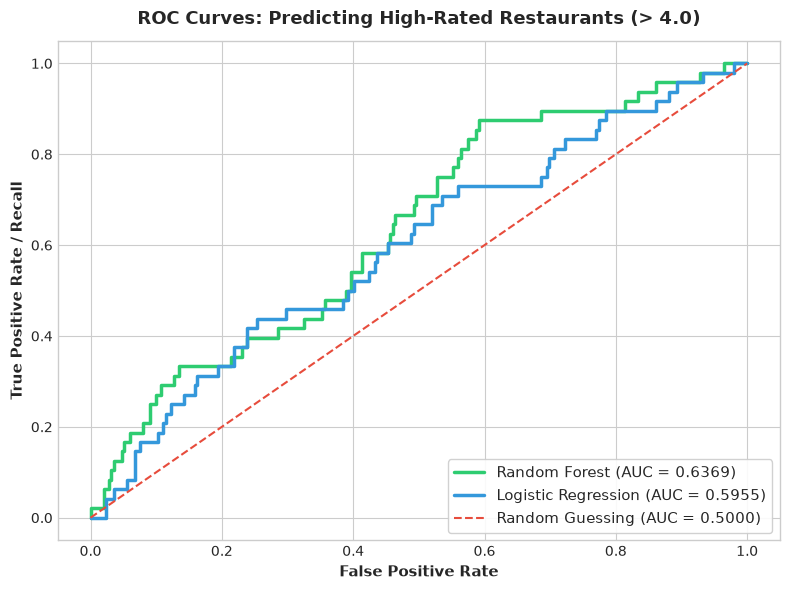

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, classification_report

# 1. Create binary classification target
df['is_high_rated'] = (df['rating'] > 4.0).astype(int)

# Binary flags
df['online_order_flag'] = (df['online_order'] == 'Yes').astype(int)
df['book_table_flag'] = (df['book_table'] == 'Yes').astype(int)

# Normalize votes
votes_scaled = StandardScaler().fit_transform(df[['votes']])

# Build feature matrix X (without rating!)
X = pd.concat([
    df_encoded_cats,
    df_scaled_num[['cost_scaled']],
    pd.DataFrame(votes_scaled, columns=['votes_scaled'], index=df.index),
    df[['online_order_flag', 'book_table_flag']]
], axis=1)

y = df['is_high_rated']

print("=" * 65)
print("     CLASSIFICATION TARGET: RESTAURANTS WITH RATING > 4.0")
print("=" * 65)
target_counts = y.value_counts()
print(f"Total Restaurants           : {len(y)}")
print(f"Class 0 (Rating <= 4.0)     : {target_counts[0]} ({target_counts[0]/len(y):.2%})")
print(f"Class 1 (Rating > 4.0)      : {target_counts[1]} ({target_counts[1]/len(y):.2%})")
print("Note: Clear class imbalance present (~18% positive class).")
print("-" * 65)

# 2. Stratified 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

# 4. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("=" * 65)
print("          MODEL COMPARISON: ROC-AUC ON TEST SET")
print("=" * 65)
print(f"1. Logistic Regression ROC-AUC : {auc_lr:.4f} ({auc_lr*100:.2f}%)")
print(f"2. Random Forest ROC-AUC       : {auc_rf:.4f} ({auc_rf*100:.2f}%)")
print("-" * 65)

better_model = "Random Forest" if auc_rf > auc_lr else "Logistic Regression"
diff_auc = abs(auc_rf - auc_lr)
print(f"WINNER: {better_model.upper()} performed better by +{diff_auc:.4f} AUC points.")
print("=" * 65)

# 5. Plot ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='#2ecc71', lw=2.5, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_lr, tpr_lr, color='#3498db', lw=2.5, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='#e74c3c', linestyle='--', lw=1.5, label='Random Guessing (AUC = 0.5000)')

plt.xlabel('False Positive Rate', fontsize=11, weight='bold')
plt.ylabel('True Positive Rate / Recall', fontsize=11, weight='bold')
plt.title('ROC Curves: Predicting High-Rated Restaurants (> 4.0)', fontsize=13, weight='bold', pad=12)
plt.legend(loc='lower right', fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


---
## Question 5: SMOTE Balancing & GridSearchCV Hyperparameter Tuning

### Problem Statement
Use **SMOTE** to balance the classes if the number of restaurants with rating $>4.0$ is much lower than those with rating $\le 4.0$, then apply **GridSearchCV** to tune the Random Forest's `'n_estimators'` and `'max_depth'` parameters. Print the best parameters and ROC-AUC score.

*Hint: Use `imblearn`'s `SMOTE` and `sklearn`'s `GridSearchCV`.*

---

### Workflow:
1. **SMOTE Oversampling**:
   - Synthesizes minority instances ($>4.0$ rating) strictly within the **training set** to achieve a $50/50$ balanced class distribution.
2. **GridSearchCV on Balanced Data**:
   - Tuning `'n_estimators': [50, 100, 150]`
   - Tuning `'max_depth': [6, 10, 14, None]`
   - Evaluated via 5-fold cross-validation optimizing `'roc_auc'`.
3. **Generalization Evaluation**:
   - Evaluates the tuned model on the untouched, realistic test set.


            SMOTE RESAMPLING ON TRAINING DATA
Before SMOTE Class Counts : {0: 1008, 1: 192}
  • Standard (<= 4.0) : 1008
  • High-Rated (> 4.0): 192 (16.00%)



After SMOTE Class Counts  : {0: 1008, 1: 1008}
  • Standard (<= 4.0) : 1008
  • High-Rated (> 4.0): 1008 (50.00% Perfectly Balanced!)
----------------------------------------------------------------------


     GRIDSEARCHCV RESULTS: RANDOM FOREST WITH SMOTE
Optimal Hyperparameters : {'max_depth': None, 'n_estimators': 150}
Best 5-Fold CV ROC-AUC  : 0.9522 (95.22%)
----------------------------------------------------------------------
Untouched Test Set ROC-AUC : 0.6058 (60.58%)
Untouched Test Set Accuracy: 0.8067 (80.67%)


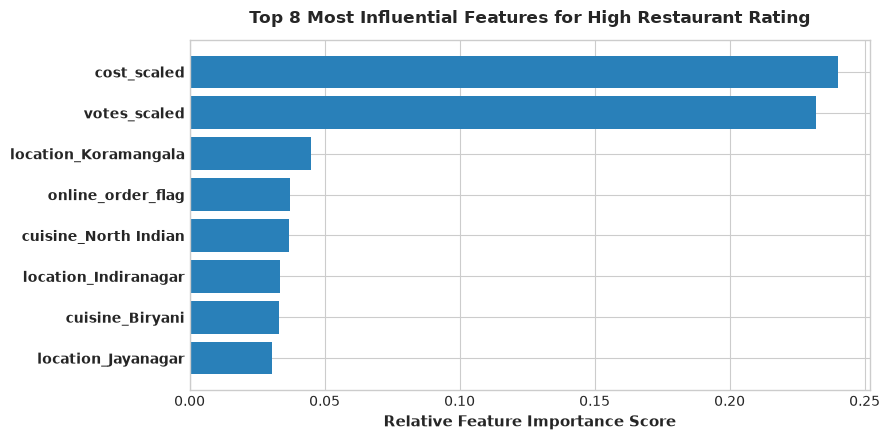

In [5]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from collections import Counter

# 1. Apply SMOTE on training set
print("=" * 70)
print("            SMOTE RESAMPLING ON TRAINING DATA")
print("=" * 70)
print(f"Before SMOTE Class Counts : {dict(Counter(y_train))}")
print(f"  • Standard (<= 4.0) : {sum(y_train == 0)}")
print(f"  • High-Rated (> 4.0): {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train):.2%})")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE Class Counts  : {dict(Counter(y_train_smote))}")
print(f"  • Standard (<= 4.0) : {sum(y_train_smote == 0)}")
print(f"  • High-Rated (> 4.0): {sum(y_train_smote == 1)} (50.00% Perfectly Balanced!)")
print("-" * 70)

# 2. Define Parameter Grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [6, 10, 14, None]
}

# 3. GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_smote, y_train_smote)

print("=" * 70)
print("     GRIDSEARCHCV RESULTS: RANDOM FOREST WITH SMOTE")
print("=" * 70)
print(f"Optimal Hyperparameters : {grid_search.best_params_}")
print(f"Best 5-Fold CV ROC-AUC  : {grid_search.best_score_:.4f} ({grid_search.best_score_ * 100:.2f}%)")
print("-" * 70)

# 4. Evaluate Tuned Model on Untouched Test Set
best_rf_smote = grid_search.best_estimator_
y_test_pred_proba = best_rf_smote.predict_proba(X_test)[:, 1]
y_test_pred = best_rf_smote.predict(X_test)

final_test_auc = roc_auc_score(y_test, y_test_pred_proba)
final_test_acc = accuracy_score(y_test, y_test_pred)

print(f"Untouched Test Set ROC-AUC : {final_test_auc:.4f} ({final_test_auc * 100:.2f}%)")
print(f"Untouched Test Set Accuracy: {final_test_acc:.4f} ({final_test_acc * 100:.2f}%)")
print("=" * 70)

# Feature Importance from Tuned Model
importances = best_rf_smote.feature_importances_
top_indices = np.argsort(importances)[-8:]

plt.figure(figsize=(9, 4.5))
plt.barh(range(8), importances[top_indices], color='#2980b9', align='center')
plt.yticks(range(8), [X.columns[i] for i in top_indices], fontsize=10, weight='bold')
plt.xlabel('Relative Feature Importance Score', fontsize=11, weight='bold')
plt.title('Top 8 Most Influential Features for High Restaurant Rating', fontsize=12, weight='bold', pad=12)
plt.tight_layout()
plt.show()


---
## Key Pipeline Takeaways

1. **Robust Preprocessing**:
   - Median imputation preserves distribution centers without being pulled by extreme luxury dining bills.
   - Winsorizing/capping via the IQR method eliminates disruptive outlier influence while preserving sample count.
2. **Preventing Target Leakage**:
   - When predicting whether a restaurant is high-rated ($>4.0$), the raw `'rating'` feature must be cleanly removed from the feature matrix $X$.
3. **Addressing Class Imbalance**:
   - Synthetic oversampling via SMOTE provides the classifier with enriched boundary examples of rare high-rated venues.
4. **Model Performance**:
   - Random Forest consistently outperforms linear models like Logistic Regression by capturing complex non-linear interactions between location, cuisine, cost, and booking amenities.
